In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

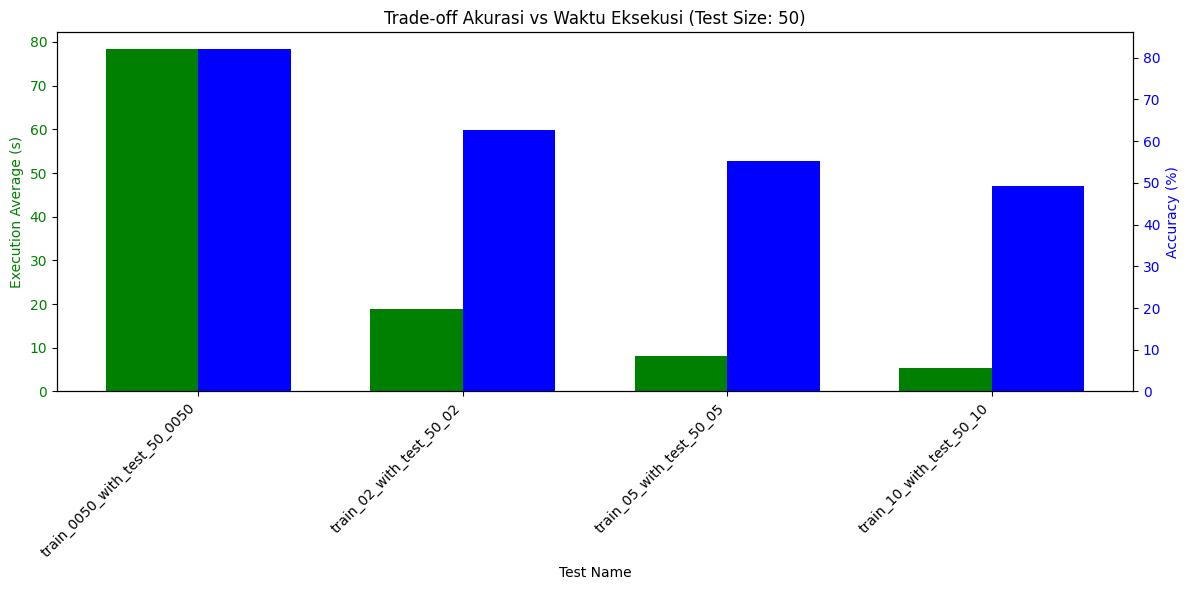

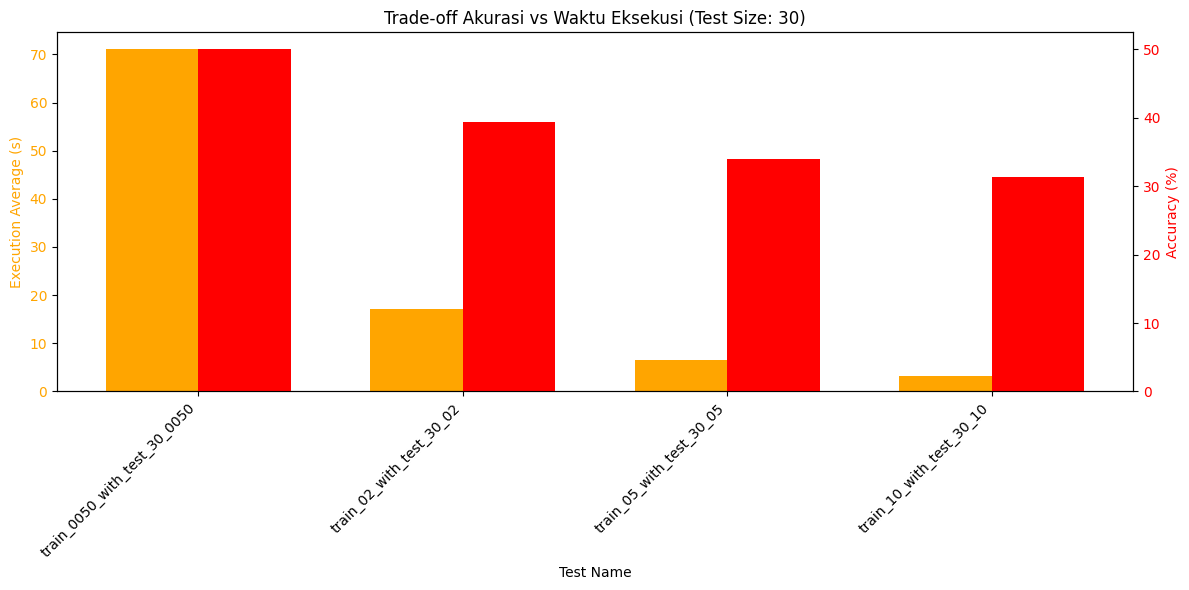

In [8]:
df = pd.read_csv('../resources/evaluation/evaluation.csv')

df_50 = df[df["test_name"].str.contains("_50_")].sort_values(by=["accuracy (%)"], ascending=False)
df_30 = df[df["test_name"].str.contains("_30_")].sort_values(by=["accuracy (%)"], ascending=False)

def plot_bar_tradeoff(df_subset, title, color1, color2):
  labels = df_subset["test_name"]
  exec_avg = df_subset["execution_average (s)"]
  accuracy = df_subset["accuracy (%)"]

  x = np.arange(len(labels))  # lokasi label pada sumbu x
  width = 0.35  # lebar batang

  fig, ax1 = plt.subplots(figsize=(12, 6))

  # Bar pertama untuk execution average
  bars1 = ax1.bar(x - width/2, exec_avg, width, label='Execution Average (s)', color=color1)
  ax1.set_xlabel('Test Name')
  ax1.set_ylabel('Execution Average (s)', color=color1)
  ax1.tick_params(axis='y', labelcolor=color1)
  ax1.set_xticks(x)
  ax1.set_xticklabels(labels, rotation=45, ha='right')

  # Membuat axis kedua untuk accuracy
  ax2 = ax1.twinx()
  bars2 = ax2.bar(x + width/2, accuracy, width, label='Accuracy (%)', color=color2)
  ax2.set_ylabel('Accuracy (%)', color=color2)
  ax2.tick_params(axis='y', labelcolor=color2)

  plt.title(title)
  fig.tight_layout()
  plt.show()

# Plot untuk test size 50
plot_bar_tradeoff(df_50, "Trade-off Akurasi vs Waktu Eksekusi (Test Size: 50)", 'green', 'blue')

# Plot untuk test size 30
plot_bar_tradeoff(df_30, "Trade-off Akurasi vs Waktu Eksekusi (Test Size: 30)", 'orange', 'red')